NMBE = -0.03 %
R^2 = 0.855
Standard deviation of absolute error = 0.057
RMSE = 0.087
MAPE = 2.27 %


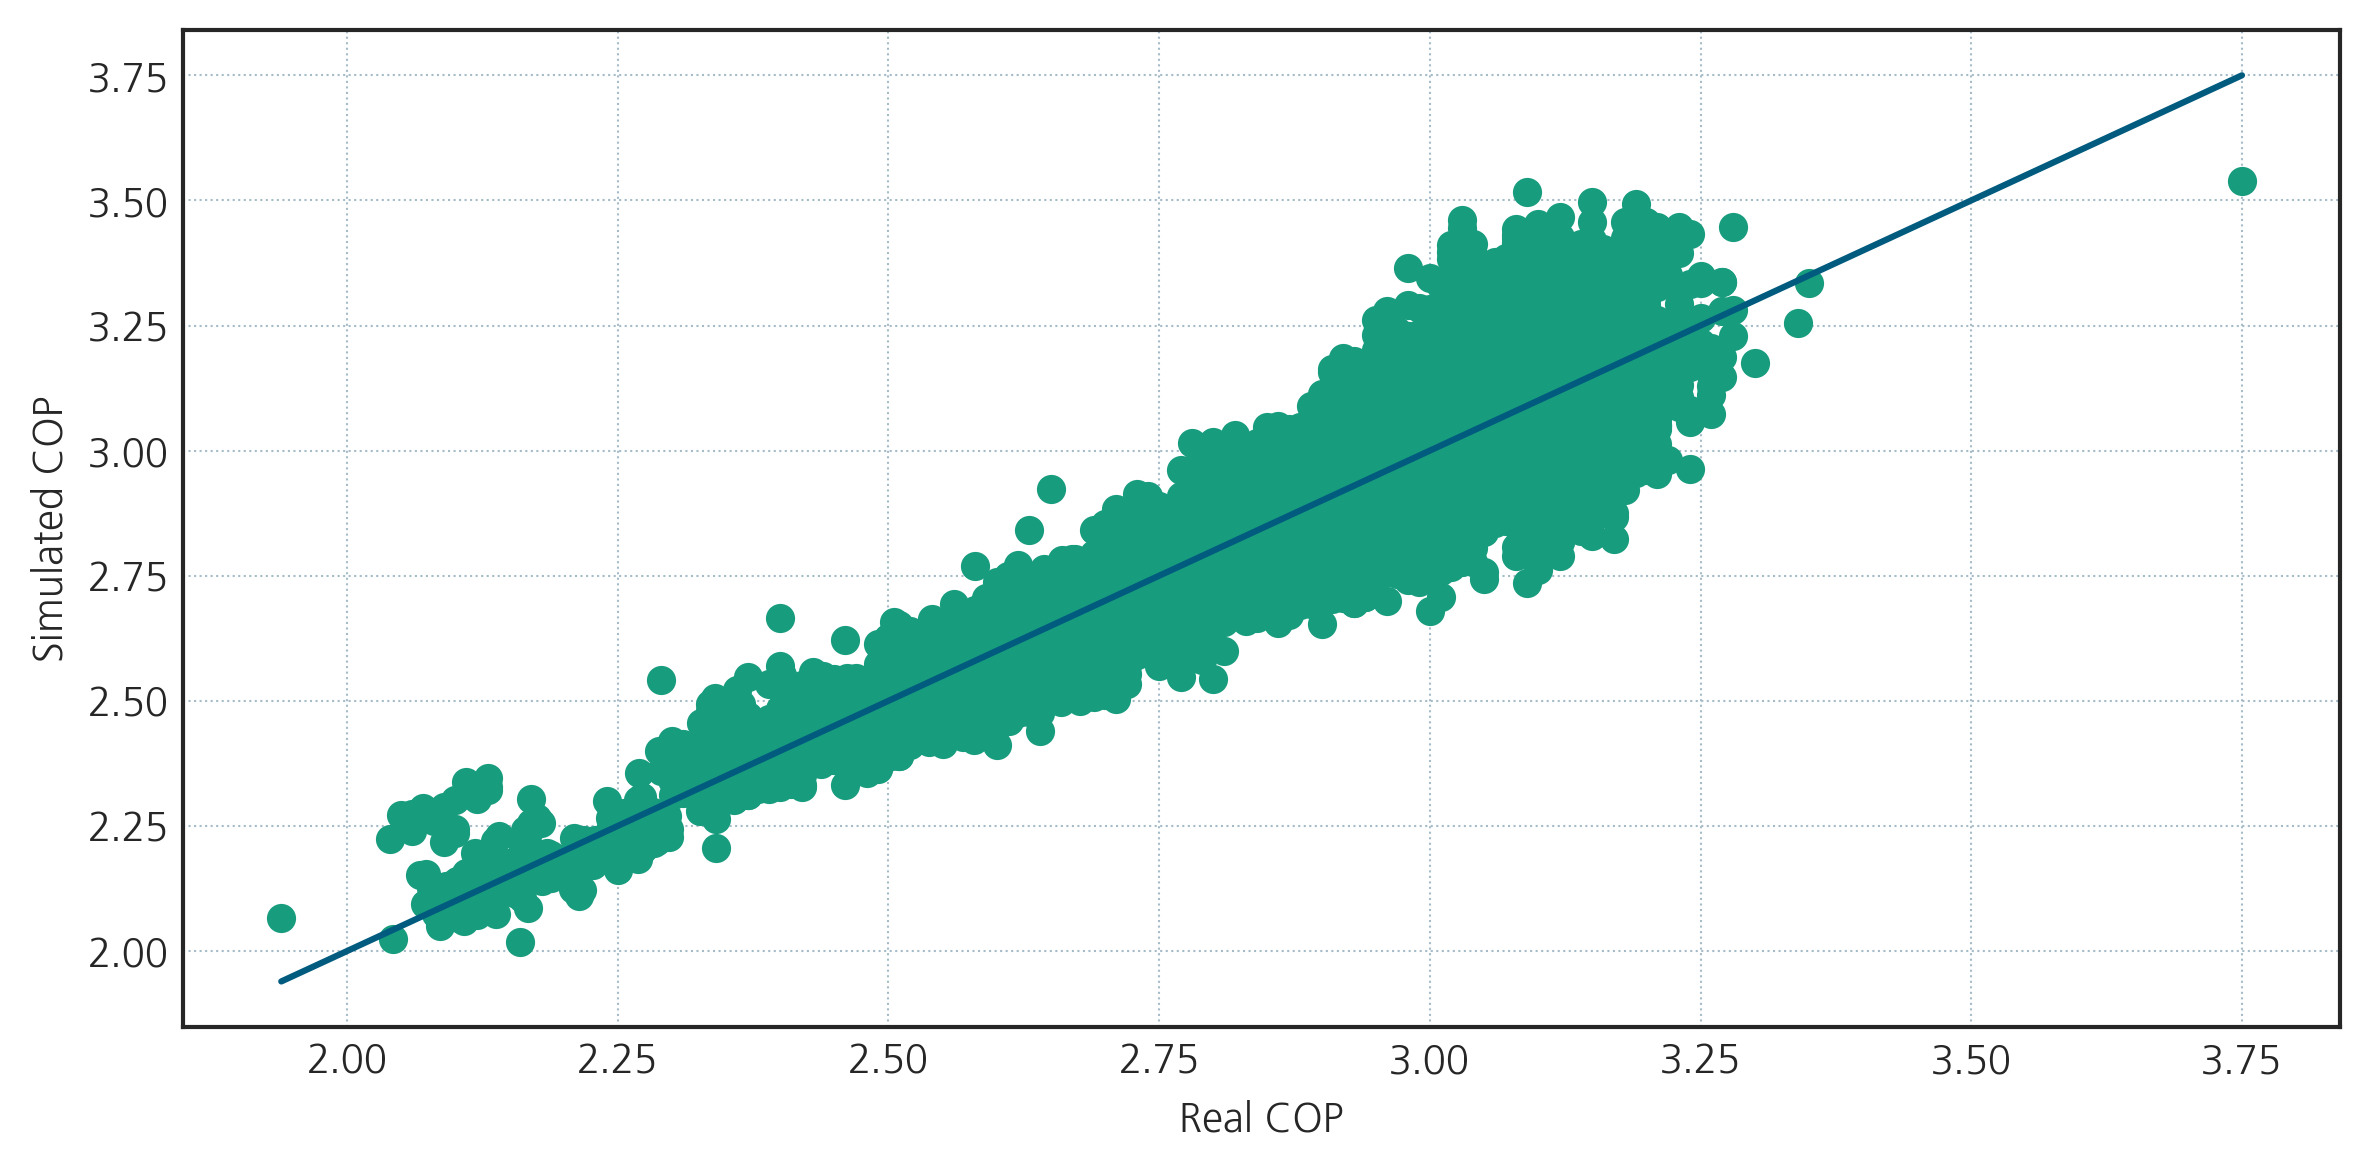

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import fhgcd_plots.main as fhgCD
from sklearn.metrics import r2_score

# -----------------------------
# Load data
# -----------------------------
#df = pd.read_csv(r'H:\Master Thesis\gitlab\ma_ronit\charmap_simulation_results6.csv', sep=',')
df = pd.read_csv(r'H:\Master Thesis\gitlab\ma_ronit\compressor_results1.csv', sep=',')

# -----------------------------
# Keep only rows where both values exist
# -----------------------------
df_clean = df[['cop_given', 'cop']].dropna().copy()

#To remove outliers of COP < 2.4
#df_clean = df[(df['cop_given'] > 2.4) & (df['cop'].notna())]

y_measured = df_clean['cop_given'].values
y_model = df_clean['cop'].values

# -----------------------------
# Metric functions
# -----------------------------
def rmse(y_measured, y_model):
    return np.sqrt(np.mean((y_model - y_measured) ** 2))

def mape(y_measured, y_model):
    return np.mean(np.abs((y_model - y_measured) / y_measured)) * 100

# -----------------------------
# Compute NMBE Normalized mean bias error
# -----------------------------

def nmbe(y_measured, y_model, p=0):
    y_measured = np.array(y_measured)
    y_model = np.array(y_model)
    n = len(y_measured)
    return np.sum(y_model - y_measured) / ((n - p) * np.mean(y_measured)) * 100

# -----------------------------
# Compute metrics
# -----------------------------
R2 = r2_score(y_measured, y_model)

error_abs = np.abs(y_model - y_measured)
std_error = np.std(error_abs, ddof=1)

rmse_value = rmse(y_measured, y_model)
mape_value = mape(y_measured, y_model)
nmbe_value = nmbe(y_measured, y_model)
print(f"NMBE = {nmbe_value:.2f} %")

print(f"R^2 = {R2:.3f}")
print(f"Standard deviation of absolute error = {std_error:.3f}")
print(f"RMSE = {rmse_value:.3f}")
print(f"MAPE = {mape_value:.2f} %")

fhgCD.set_matplotlib_style("grid", "official")

# -----------------------------
# Plot simulated COP vs real COP
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 4))

# line of perfect agreement
x_line = np.linspace(min(y_measured.min(), y_model.min()),
                     max(y_measured.max(), y_model.max()), 100)

ax.plot(
    y_measured,
    y_model,
    'o'
#    label=(
#        f'$R^2$ = {R2:.3f}\n'
#        f'RMSE = {rmse_value:.3f}\n'
#        f'MAPE = {mape_value:.2f} %\n'
#        f'$\\sigma$ = {std_error:.3f}\n'
#        f'NMBE= {nmbe_value:.2f} %'
#    )
)

ax.plot(x_line, x_line, '-')

ax.set_xlabel('Real COP')
ax.set_ylabel('Simulated COP')
#ax.set_title('Comparison of Simulated COP and Real COP')
ax.grid(True)
#ax.legend(fontsize=12)

plt.tight_layout()
#plt.savefig("COP_compare_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

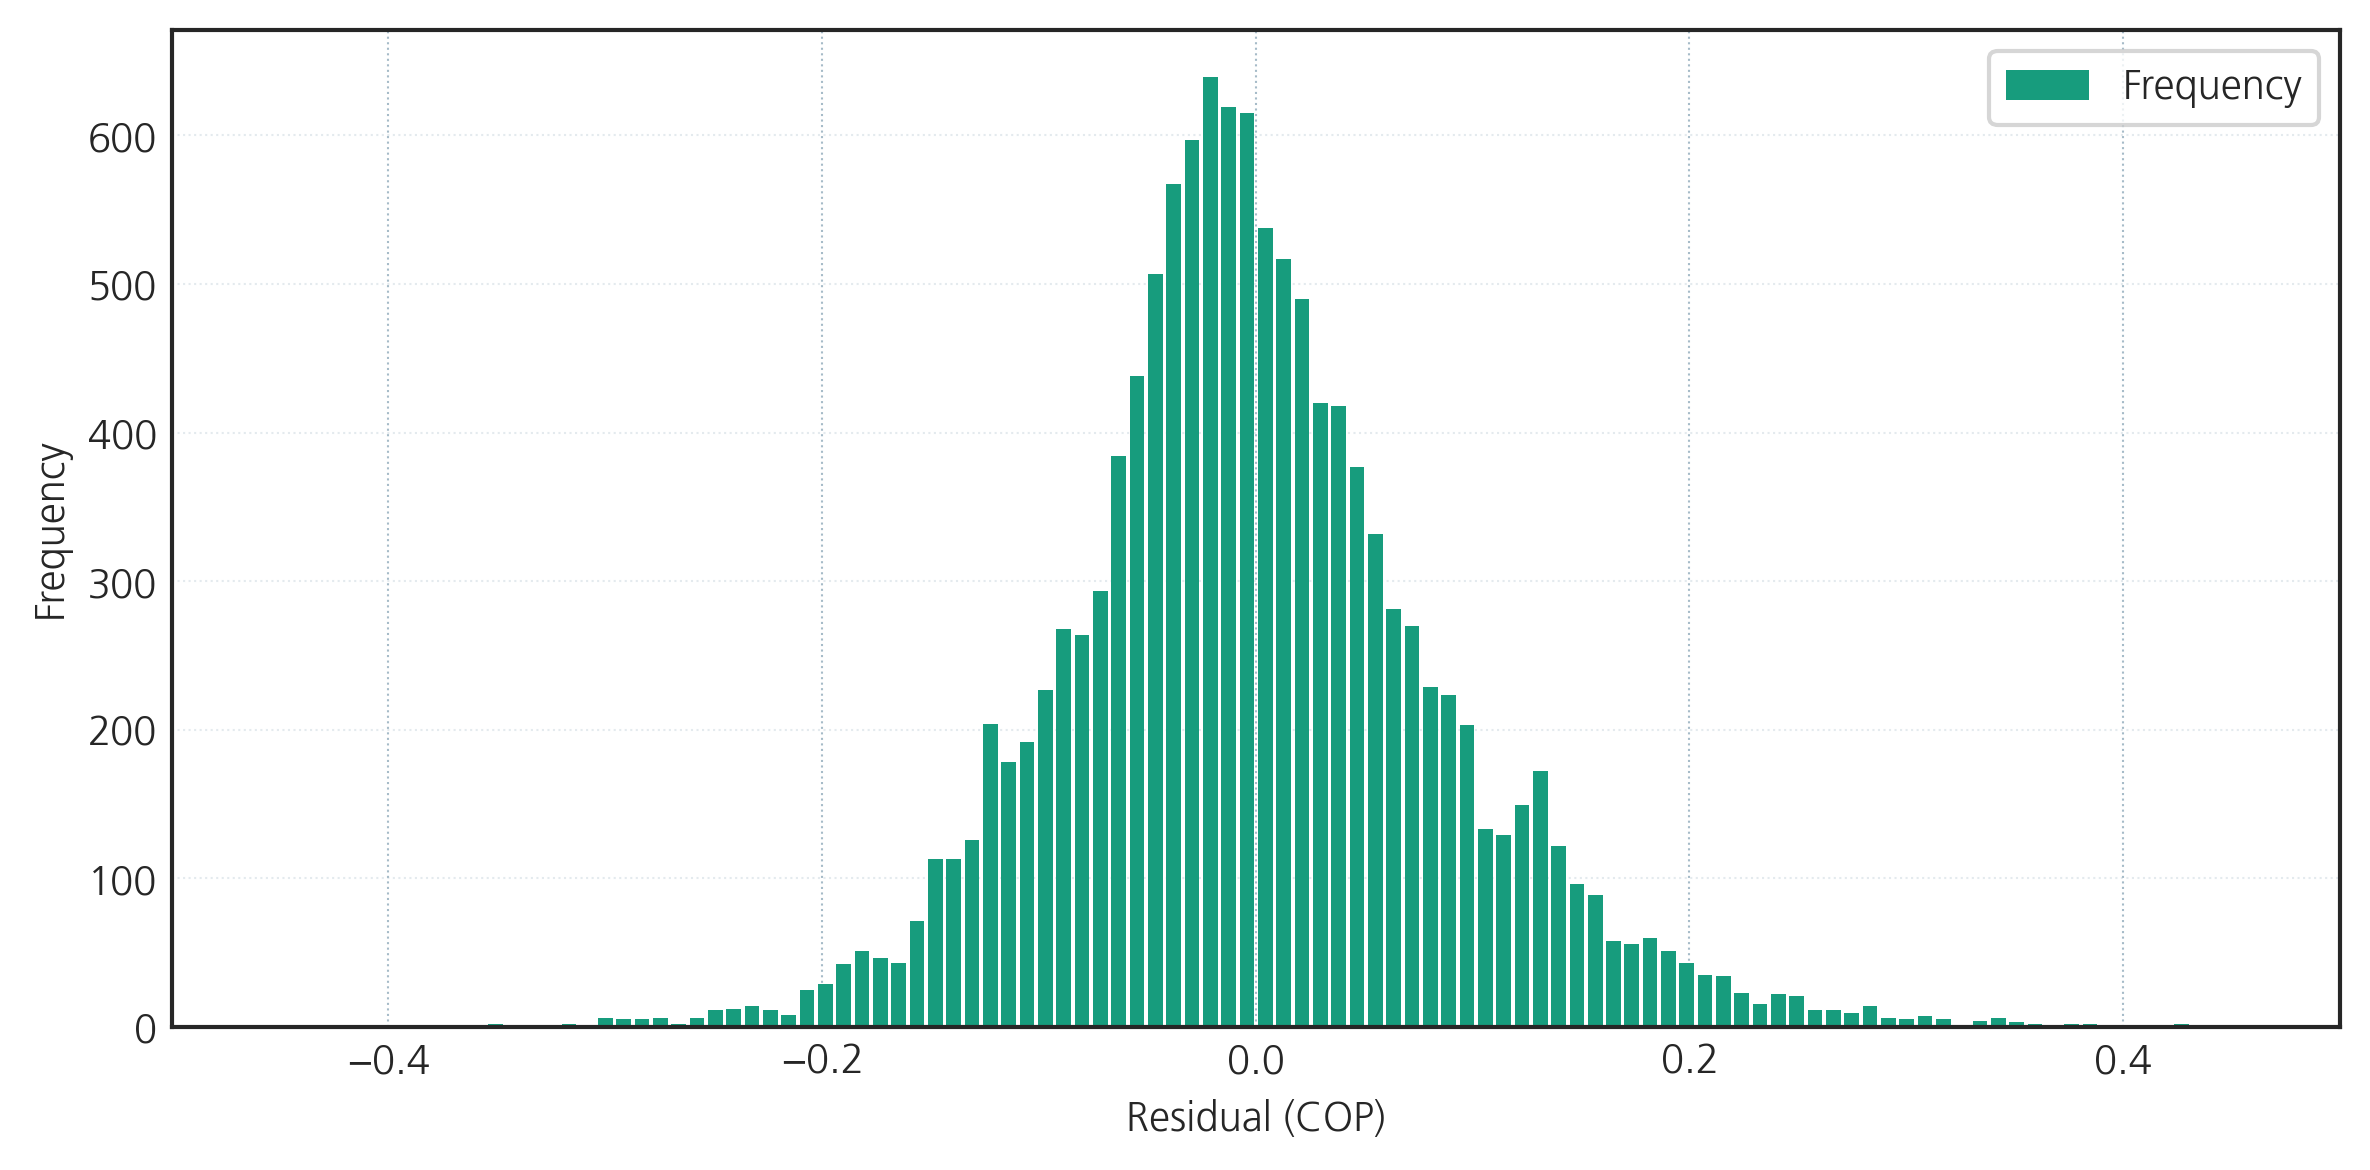

In [27]:
'''
Plot frequency of residual of COP
'''
import matplotlib.pyplot as plt
import pandas as pd
import fhgcd_plots.main as fhgCD
import matplotlib.dates as mdates
import numpy as np



#df = pd.read_csv('charmap_simulation_results6_count.csv',sep=',')
#df1 = pd.read_excel('data/process_data/Manheim_data_cleaned4.xlsx', sheet_name="Mannheim_rlgwp_2025-10-22", header=0,skiprows=range(1, 5)) #Load profile data
#df2 = pd.read_csv('charmap_simulation_results6full.csv',sep=',')
#df2 = pd.read_csv(r'H:\Master Thesis\gitlab\ma_ronit\charmap_simulation_results6.csv', sep=',')
df2 = pd.read_csv(r'H:\Master Thesis\gitlab\ma_ronit\compressor_results1.csv', sep=',')

fhgCD.set_matplotlib_style("grid", "official")



# Absolute error
error_abs = df2['cop'].values - df2['cop_given'].values


fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(error_abs, bins='fd',rwidth=0.8,label='Frequency')

ax.set_xlabel('Residual (COP)')
ax.set_ylabel('Frequency')
#ax.set_title('Frequency distribution of residuals of COP')
ax.grid(True, axis="y", alpha=0.3, zorder=0)
ax.legend()
ax.set_xlim(-0.5,0.5)
plt.savefig("COP residual barplot.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


